In [1]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import multiprocessing as mp
import time
import numpy as np
import itertools
import tools21cm as t2c
from scipy import stats
from tqdm import tqdm
import astropy.units as u
import astropy.constants as cst

plt.rcParams["font.family"] = "serif"

from astropy.io import fits
import casacore.tables as ct

2024-06-03 14:50:05.806197: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """Generate galactic synchrotron foreground data.

    Parameters:
    - z (float or array-like): Redshift value(s) for which to generate the data.
    - ncells (int): Number of cells in each dimension.
    - boxsize (float): Size of the box in units of distance.
    - rseed (bool, optional): Whether to use a random seed for reproducibility. Default is False.

    Returns:
    - gf_data (ndarray): Generated galactic synchrotron foreground data.
    - l_cb (ndarray): Angular wavenumbers corresponding to the generated data.
    """
    if isinstance(z, float):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if rseed:
        np.random.seed(rseed)

    X = np.random.normal(size=(ncells, ncells))
    Y = np.random.normal(size=(ncells, ncells))
    _, A150, beta_, _, _ = 150, 5.13 * 1e-4, 2.34, 2.8, 0.1

    for i in range(0, z.size):
        _ = t2c.cosmo.z_to_nu(z[i])
        U_cb = (
            (np.mgrid[-ncells / 2 : ncells / 2, -ncells / 2 : ncells / 2] + 0.5)
            * t2c.cosmo.z_to_cdist(z[i])
            / boxsize
        )
        l_cb = 2 * np.pi * np.sqrt(U_cb[0, :, :] ** 2 + U_cb[1, :, :] ** 2)
        C_syn = A150 * (1000 / l_cb) ** beta_
        solid_angle = boxsize**2 / t2c.cosmo.z_to_cdist(z[i]) ** 2
        AA = np.sqrt(solid_angle * C_syn / 2)
        T_four = AA * (X + Y * 1j) * np.sqrt(2)
        T_real = np.abs(np.fft.ifft2(T_four))  # in Jansky
        gf_data[..., i] = T_real
        # gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
        # gf_data[..., i] = t2c.telescope_functions.kelvin_2_jansky(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)

    return gf_data.squeeze(), l_cb


def synchrotron_image(z, ncells, boxsize, seed=False):
    """Generate a synchrotron image.

    Parameters:
    - z (float): Redshift value.
    - ncells (int): Number of cells in each dimension.
    - boxsize (float): Size of the box in Mpc.
    - seed (bool, optional): Whether to use a fixed seed for random number generation. Default is False.

    Returns:
    - T_real (ndarray): The real part of the synchrotron image.
    - l_cb (ndarray): The angular scale of the synchrotron image.
    """
    if seed:
        np.random.seed(seed)

    X = np.random.normal(size=(ncells, ncells))
    Y = np.random.normal(size=(ncells, ncells))

    A150, beta = 5.13 * 1e-4, 2.34

    U_cb = (
        (np.mgrid[-ncells / 2 : ncells / 2, -ncells / 2 : ncells / 2] + 0.5)
        * t2c.cosmo.z_to_cdist(z)
        / boxsize
    )
    l_cb = 2 * np.pi * np.sqrt(U_cb[0, :, :] ** 2 + U_cb[1, :, :] ** 2)
    C_syn = A150 * (1000 / l_cb) ** beta
    solid_angle = boxsize**2 / t2c.cosmo.z_to_cdist(z) ** 2
    AA = np.sqrt(solid_angle * C_syn / 2)
    T_four = AA * (X + Y * 1j) * np.sqrt(2)
    T_real = np.abs(np.fft.ifft2(T_four))

    return T_real, l_cb


def telescope_beam_pattern(x, y, D, z):
    """Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq = t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    theta_0 = 0.6 * fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))


def gaussian_source_2d(x, y, cov):
    """Calculates the telescope beam pattern for given coordinates and
    parameters.

    Parameters:
    x (float): The x-coordinate.
    y (float): The y-coordinate.
    D (float): The diameter of the telescope.
    z (float): The redshift value.

    Returns:
    float: The telescope beam pattern value at the given coordinates.
    """
    mean = np.array([0, 0])  # Mean of the Gaussian source
    cov = np.array(
        [
            [(cov[0] * u.arcsec).to("rad").value, 0],
            [0, (cov[1] * u.arcsec).to("rad").value],
        ]
    )
    x_diff = x - mean[0]
    y_diff = y - mean[1]
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * (
        x_diff**2 * inv_cov[0, 0]
        + y_diff**2 * inv_cov[1, 1]
        + 2 * x_diff * y_diff * inv_cov[0, 1]
    )
    prefactor = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)


def hirax_layout(N_ant, range):
    """Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x = np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y = np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)


def random_layout(N_ant, range, seed):
    """Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X = np.random.uniform(range[0], range[1], N_ant)
    Y = np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X, Y)).reshape(-1, 2)


def random_layout_concentrated(N_ant, range_large, range_small, seed):
    """Generate a random layout of antennas with a concentration of points
    within a smaller range.

    Parameters:
    - N_ant (int): The total number of antennas to generate.
    - range_large (tuple): The range of coordinates for generating antennas within the larger range.
    - range_small (tuple): The range of coordinates for generating antennas within the smaller range.
    - seed (int): The seed value for the random number generator.

    Returns:
    - numpy.ndarray: An array of shape (N_ant, 2) containing the generated antenna coordinates.
    """
    np.random.seed(seed)
    # Generate antennas within the larger range
    X_large = np.random.uniform(range_large[0], range_large[1], N_ant)
    Y_large = np.random.uniform(range_large[0], range_large[1], N_ant)

    # Generate antennas within the smaller range
    X_small = np.random.uniform(range_small[0], range_small[1], N_ant)
    Y_small = np.random.uniform(range_small[0], range_small[1], N_ant)

    # Concatenate the generated points from both ranges
    X = np.concatenate((X_large, X_small))
    Y = np.concatenate((Y_large, Y_small))

    return np.dstack((X, Y)).reshape(-1, 2)


def random_normal_layout(N_ant, range, seed):
    """Generate a random layout of antennas with normally distributed
    coordinates.

    Parameters:
    - N_ant (int): The number of antennas to generate.
    - range (tuple): A tuple (mean, std) specifying the mean and standard deviation of the normal distribution.
    - seed (int): The seed value for the random number generator.

    Returns:
    - numpy.ndarray: An array of shape (N_ant, 2) containing the generated antenna coordinates.
    """
    np.random.seed(seed)
    X = np.random.normal(range[0], range[1], N_ant)
    Y = np.random.normal(range[0], range[1], N_ant)

    return np.dstack((X, Y)).reshape(-1, 2)


def ring_layout(N_ring, N_center, radius_range, center_range, seed):
    """Generates a layout of antennas with a specified number of antennas in a
    ring and within the center. Antennas within the center can also be
    generated using the ring method.

    Parameters
    ----------
    N_ring : int
        Number of antennas to generate in the ring.
    N_center : int
        Number of antennas to generate within the center.
    radius_range : tuple
        Tuple specifying the range of the ring radius.
        It should be in the format (min_radius, max_radius).
    center_range : tuple
        Tuple specifying the range of coordinates in which antennas within the center will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)

    # Generate antennas in the ring
    theta_ring = np.random.uniform(0, 2 * np.pi, N_ring)
    radius_ring = np.random.uniform(radius_range[0], radius_range[1], N_ring)
    X_ring = radius_ring * np.cos(theta_ring)
    Y_ring = radius_ring * np.sin(theta_ring)

    # Generate antennas within the center using the ring method
    theta_center = np.random.uniform(0, 2 * np.pi, N_center)
    radius_center = np.random.uniform(
        0, min(center_range[1], max(radius_range)), N_center
    )
    X_center = radius_center * np.cos(theta_center)
    Y_center = radius_center * np.sin(theta_center)

    # Combine antennas from ring and center
    X = np.concatenate((X_ring, X_center))
    Y = np.concatenate((Y_ring, Y_center))

    return np.dstack((X, Y)).reshape(-1, 2)


def median_index(list):
    """Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.median(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index


def arbitrary_index(list, value):
    """Find the index of the closest element in a list to a given value.

    Parameters:
    list (array-like): The list of values.
    value (float): The value to find the closest index to.

    Returns:
    int: The index of the closest element in the list to the given value.
    """
    closest_index = np.abs(list - value).argmin()
    return closest_index


def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant = len(xyz_coord)  # Number of antennas
    N_B = int(N_ant * (N_ant - 1) / 2)  # Number of baselines
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    pair_comb = list(itertools.combinations(range(N_ant), 2))  # Get pair of antennas

    baseline_coord = np.empty(
        (N_B, xyz_coord.shape[1])
    )  # Initialize a baseline vectors array
    visibility_matrix = np.zeros(
        (N_ant, N_ant), dtype=np.complex128
    )  # Initialize a visibility array
    visibility_list = np.empty(N_B, dtype=np.complex128)  # Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb = pair_comb[i]

        # Calculate distance between antennas
        uv = (xyz_coord[bb] - xyz_coord[aa]) / lam
        baseline_coord[i] = uv

        # Calculate the fringe pattern
        fringe = np.exp(
            -2j * np.pi * (uv[0] * lmn_coord[:, 0] + uv[1] * lmn_coord[:, 1])
        )

        # Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        # Calculate visibility for the current baseline
        visibility = np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i] = visibility

        # Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility)  # Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord


def visibility_rotation_synthesis(
    lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant
):
    N_B = int(N_ant * (N_ant - 1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb = list(itertools.combinations(range(N_ant), 2))  # Get pair of antennas
    visibility_matrix = np.zeros(
        (N_ant, N_ant), dtype=np.complex128
    )  # Initialize a visibility array
    visibility_list = np.empty(N_B, dtype=np.complex128)  # Initialize a visibility list

    for i in range(N_B):
        aa, bb = pair_comb[i]
        uv = rotated_baselines[i]
        fringe = np.exp(
            -2j * np.pi * (uv[0] * lmn_coord[:, 0] + uv[1] * lmn_coord[:, 1])
        )
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility = np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i] = visibility

        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix


def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to("rad").value, delta.to("rad").value

    return np.array(
        [
            [np.sin(HA), np.cos(HA)],
            [-np.sin(delta) * np.cos(HA), np.sin(delta) * np.sin(HA)],
        ]
    )


def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """Computes visibility correlation and baseline distances from a given
    baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices = np.linspace(0, N_B - 1, N_B)
    indices_combinations = list(
        itertools.product([index], range(N_B))
    )  # Generate combinations
    baseline_distances = np.empty(
        (len(indices), 2)
    )  # Create empty array for calculating distance between two vectors
    vis_corr = np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i] = visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i] = baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm = np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm


def visibility_matrix_func_new_method(
    xyz_coord, sky_coord, redshift, I_sky, beam_pattern
):
    """Calculates the visibility matrix, visibility list, and baseline
    coordinates for interferometry measurements.

    Parameters:
    - xyz_coord (numpy.ndarray): Array of shape (N_ant, 3) containing the x, y, and z coordinates of the antennas.
    - sky_coord (numpy.ndarray): Array of shape (N_sky,) containing the sky coordinates.
    - redshift (float): The redshift value.
    - I_sky (numpy.ndarray): Array of shape (N_sky,) containing the sky intensity values.
    - beam_pattern (numpy.ndarray): Array of shape (N_sky,) containing the beam pattern values.

    Returns:
    - visibility_list (numpy.ndarray): Array of shape (N_B,) containing the visibility values for each baseline.
    - visibility_matrix (numpy.ndarray): Array of shape (N_ant, N_ant) containing the visibility values for each antenna pair.
    - baseline_coord (numpy.ndarray): Array of shape (N_B, 3) containing the baseline coordinates.
    """
    l_coord, m_coord = np.meshgrid(sky_coord, sky_coord)
    N_ant = len(xyz_coord)
    N_B = int(N_ant * (N_ant - 1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb = list(itertools.combinations(range(N_ant), 2))
    baseline_coord = np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix = np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list = np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb = pair_comb[i]
        uv = (xyz_coord[bb] - xyz_coord[aa]) / lam
        baseline_coord[i] = uv
        fringe = np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis = np.sum(fringe * I_sky * beam_pattern)
        visibility_list[i] = vis
        visibility_matrix[aa, bb] = vis
        visibility_matrix[bb, aa] = np.conj(vis)

    return visibility_list, visibility_matrix, baseline_coord


def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin = np.linspace(u_min, u_max, int(bin_len / bin_res))

    uv_plane_binned = stats.binned_statistic_2d(
        x=baselines[:, 0],
        y=baselines[:, 1],
        values=vis_list,
        statistic="sum",
        bins=[uv_bin, uv_bin],
    ).statistic
    uv_sampl_binned = stats.binned_statistic_2d(
        x=baselines[:, 0],
        y=baselines[:, 1],
        values=vis_list,
        statistic="count",
        bins=[uv_bin, uv_bin],
    ).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x = np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x


def powerspec_1d(uv_bins, fft_img, FoV):
    """Calculate the 1D power spectrum of an image.

    Parameters:
    - uv_bins (array-like): The bins for the UV coordinates.
    - fft_img (array-like): The Fourier transformed image.
    - FoV (float): The field of view of the image in degrees.

    Returns:
    - bin_centre (array-like): The bin centers of the power spectrum.
    - statistic (array-like): The power spectrum values corresponding to each bin.

    The function calculates the 1D power spectrum of an image by first calculating the UV coordinates
    based on the provided bins. It then calculates the radial distance (l) for each UV coordinate.
    The absolute value of the Fourier transformed image is squared and divided by the solid angle
    to obtain the power spectrum. The power spectrum is then binned using the provided UV bins,
    and the bin centers and corresponding power spectrum values are returned.
    """
    solid_angle = 2 * np.pi * (1 - np.cos(np.deg2rad(FoV.value * u.deg / 2)))

    if len(fft_img) == len(uv_bins):
        uv_mesh = np.meshgrid(uv_bins, uv_bins)
        uv_mesh_stacked = np.stack((uv_mesh[1], uv_mesh[0]), axis=-1)
        uv_list = uv_mesh_stacked.reshape((len(uv_bins) ** 2, 2))

    else:
        uv_mesh = np.meshgrid(uv_bins[0:-1], uv_bins[0:-1])
        uv_mesh_stacked = np.stack((uv_mesh[1], uv_mesh[0]), axis=-1)
        uv_list = uv_mesh_stacked.reshape((len(uv_bins[0:-1]) ** 2, 2))

    l_val = 2 * np.pi * (uv_list[:, 0] ** 2 + uv_list[:, 1] ** 2) ** 0.5

    fftimg_abs = np.abs(fft_img) ** 2 / solid_angle
    fftimg_abs_reshape = fftimg_abs.reshape(-1)

    fft_img_binned = stats.binned_statistic(
        l_val, fftimg_abs_reshape, statistic="mean", bins=len(uv_bins) - 1
    )
    bin_centre = [
        (fft_img_binned.bin_edges[i] + fft_img_binned.bin_edges[i + 1]) / 2
        for i in range(len(fft_img_binned.bin_edges) - 1)
    ]

    return bin_centre, fft_img_binned.statistic


def filter_baselines(baselines, visibilities, u_freq, v_freq):
    """Filters baselines and corresponding visibilities based on the range of
    frequencies. This is so that the baselines outside the frequency range of
    the fft image are removed.

    Parameters:
    baselines (list): List of baseline coordinates.
    visibilities (list): List of corresponding visibilities.
    u_freq (list): List of u frequencies.
    v_freq (list): List of v frequencies.

    Returns:
    filtered_baselines (ndarray): Numpy array of filtered baseline coordinates.
    filtered_visibilities (ndarray): Numpy array of filtered visibilities.
    """
    filtered_baselines = []
    filtered_visibilities = []

    for baseline, visibility in zip(baselines, visibilities):
        x, y = baseline
        # Check if baseline coordinates are within the range of frequencies
        if (np.min(u_freq) <= x <= np.max(u_freq)) and (
            np.min(v_freq) <= y <= np.max(v_freq)
        ):
            filtered_baselines.append(baseline)
            filtered_visibilities.append(visibility)
    return np.array(filtered_baselines), np.array(filtered_visibilities)


def bare_estimator_func(baselines, visibilities, rshift, D, num_bins, bin_type="log"):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6 * fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)

    if bin_type == "log":
        log_blmag_sorted = np.log10(blmag_sorted)
    if bin_type == "linear":
        log_blmag_sorted = blmag_sorted
    bins = np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices = np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values = {i: [] for i in range(1, num_bins + 1)}
    # Group the y values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator = []
    ell_mean = []
    estimate = []

    for key in bin_values.keys():
        bin_len = len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len * (bin_len - 1) / 2)

    for key in bin_values.keys():
        bin_len = len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len * (bin_len - 1) / 2)

        numerator = 0
        denominator = 0
        est_numerator = 0
        est_denominator = 0
        ell_numerator = 0
        ell_denominator = 0
        pair_combs = list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance = (bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0])
            distance_norm = np.linalg.norm(distance)
            weight = np.exp(-(distance_norm**2) / sigma_0**2)

            visibility_product = bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            numerator += weight * visibility_product
            denominator += weight * V_0 * np.exp(-(distance_norm**2) / (sigma_0**2))

            u_i = bin_values[key][pair_combs[i][0]][0][0]
            v_i = bin_values[key][pair_combs[i][0]][0][1]
            l_i = 2 * np.pi * (u_i**2 + v_i**2) ** 0.5
            ell_numerator += weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

            est_numerator += (weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * 5.13 * 1e-4 * (1000 / l_i) ** 2.34)
            est_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

        bare_estimator.append(np.abs(numerator) ** 2 / denominator)
        ell_mean.append(ell_numerator / ell_denominator)
        estimate.append(est_numerator / est_denominator)

    return np.array(bare_estimator), np.array(ell_mean), np.array(estimate)


def bare_estimator_func_v2(
    baselines, visibilities, rshift, D, num_bins, bin_type="log"
):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6 * fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)

    if bin_type == "log":
        log_blmag_sorted = np.log10(blmag_sorted)
    if bin_type == "linear":
        log_blmag_sorted = blmag_sorted
    bins = np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices = np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values = {i: [] for i in range(1, num_bins + 1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append(
            (blcoord_sorted[i], blmag_sorted[i], vis_sorted[i])
        )

    bare_estimator = []
    ell_mean = []

    for key in bin_values.keys():
        bin_len = len(bin_values[key])

        print(
            "Key: ",
            key,
            "; Key legnth: ",
            bin_len,
            "; Combinations: ",
            bin_len * (bin_len - 1) / 2,
        )

    for key in bin_values.keys():
        bin_len = len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        be_numerator = 0
        be_denominator = 0
        ell_numerator = 0
        ell_denominator = 0
        cntr = 0

        pair_combs = list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance = (bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0])
            distance_norm = np.linalg.norm(distance)

            if distance_norm <= sigma_0:
                continue

            cntr += 1
            weight = np.exp(-(distance_norm**2) / sigma_0**2)
            visibility_product = bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            be_numerator += weight * visibility_product
            be_denominator += weight * V_0 * np.exp(-(distance_norm**2) / (sigma_0**2))

            u_i = bin_values[key][pair_combs[i][0]][0][0]
            v_i = bin_values[key][pair_combs[i][0]][0][1]
            l_i = 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
            ell_numerator += weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len * (bin_len - 1) / 2, "; Actual combinations: ", cntr)

        if distance_norm <= sigma_0:
            continue

        bare_estimator_val = np.abs(be_numerator) / be_denominator
        bare_estimator.append(bare_estimator_val)
        ell_mean_val = ell_numerator / ell_denominator
        ell_mean.append(ell_mean_val)

    return np.array(bare_estimator), np.array(ell_mean)


def bare_estimator_func_v3(
    baselines, visibilities, rshift, D, num_bins, bin_type="log"):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6 * fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)

    if bin_type == "log":
        blmag_sorted_transformed = np.log10(blmag_sorted)
    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
    else:
        raise ValueError("Unsupported bin_type")
    
    bins = np.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), num_bins)
    bin_indices = np.digitize(blmag_sorted_transformed, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values = {i: [] for i in range(1, num_bins + 1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    for key in bin_values.keys():
        bin_len = len(bin_values[key])
        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len * (bin_len - 1) / 2)

    num_processes = len(bin_values.keys())
    # create a pool of processes
    pool = mp.Pool(processes=num_processes)
    # map the function to the input data and calculate the results
    results = pool.starmap(compute_vals, [(key, bin_values, sigma_0, V_0) for key in bin_values.keys()])
    pool.close()
    pool.join()

    # Combine the results from the processes
    bare_estimator = []
    ell_mean = []
    var_squared = []
    for result in results:
        bare_estimator.append(result[0])
        ell_mean.append(result[1])
        var_squared.append(result[2])

    np_bare_estimator = np.array(bare_estimator)
    np_ell_mean = np.array(ell_mean)
    np_var_squared = np.array(var_squared)

    # remove zero values from the arrays
    np_bare_estimator = np_bare_estimator[np_bare_estimator != 0]
    np_ell_mean = np_ell_mean[np_ell_mean != 0]
    np_var_squared = np_var_squared[np_var_squared != 0]

    return np_bare_estimator, np_ell_mean, np.abs(np_var_squared)


def compute_vals(bin_values, sigma_0, V_0):
    bin_len = len(bin_values)

    if bin_len == 0 or bin_len == 1:
        return 0, 0, 0

    be_numerator = 0
    be_denominator = 0
    ell_numerator = 0
    ell_denominator = 0
    cntr = 0
    Eb_square_mean_numerator = 0
    Eb_mean_square_numerator = 0
    Eb_denominator = 0

    pair_combs = list(itertools.combinations(range(bin_len), 2))
    for i in range(len(pair_combs)):
        distance = bin_values[pair_combs[i][0]][0] - bin_values[pair_combs[i][1]][0]
        distance_norm = np.linalg.norm(distance)

        if distance_norm <= sigma_0:
            continue

        cntr += 1
        weight = np.exp(-(distance_norm**2) / sigma_0**2)
        visibility_product = bin_values[pair_combs[i][0]][2] * np.conj(bin_values[pair_combs[i][1]][2])
        be_numerator += weight * visibility_product
        be_denominator += weight * V_0 * np.exp(-(distance_norm**2) / (sigma_0**2))

        u_i = bin_values[pair_combs[i][0]][0][0]
        v_i = bin_values[pair_combs[i][0]][0][1]
        l_i = 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
        ell_numerator += weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * l_i
        ell_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

        Eb_square_mean_numerator += (weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * 5.13 * 1e-4 * (1000 / l_i) ** 2.34) ** 2
        Eb_mean_square_numerator += (weight * np.exp(-(distance_norm**2) / (sigma_0**2)) * 5.13 * 1e-4 * (1000 / l_i) ** 2.34)
        Eb_denominator += weight * np.exp(-(distance_norm**2) / (sigma_0**2))

    if distance_norm <= sigma_0:
        return 0, 0, 0

    bare_estimator = np.abs(be_numerator) / be_denominator
    ell_mean = ell_numerator / ell_denominator
    var_squared = (Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator) ** 2)

    return bare_estimator, ell_mean, var_squared


def _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    bins = np.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), num_bins)
    bin_indices = np.digitize(blmag_sorted_transformed, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values = {i: [] for i in range(1, num_bins + 1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    return bin_values


def _splice_values_equal_bins(blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    # Calculate number of elements per bin
    elements_per_bin = len(blmag_sorted) // num_bins
    remainder = len(blmag_sorted) % num_bins

    bin_values = {}

    # Distribute elements into bins
    start_idx = 0
    for i in range(num_bins):
        end_idx = start_idx + elements_per_bin
        if i < remainder:
            end_idx += 1  # Distribute remainder elements
        bin_values[i + 1] = list(zip(blcoord_sorted[start_idx:end_idx], blmag_sorted[start_idx:end_idx], vis_sorted[start_idx:end_idx],))
        start_idx = end_idx
    return bin_values


def bare_estimator_func_v4(baselines, visibilities, rshift, D, num_bins, bin_type="log"):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6 * fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)
    print("Length of input arrays: ", len(blmag_sorted))

    if bin_type == "log":
        blmag_sorted_transformed = np.log10(blmag_sorted)
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
        
    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        bin_values = _splice_values_equal_bins(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")

    for key in bin_values.keys():
        bin_len = len(bin_values[key])
        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len * (bin_len - 1) / 2)

    # create a pool of processes
    pool = mp.Pool(processes=num_bins)
    # map the function to the input data and calculate the results
    results = pool.starmap(
        compute_vals, [(bin_values[key], sigma_0, V_0) for key in bin_values.keys()]
    )
    pool.close()
    pool.join()

    # Combine the results from the processes
    bare_estimator = []
    ell_mean = []
    var_squared = []
    for result in results:
        bare_estimator.append(result[0])
        ell_mean.append(result[1])
        var_squared.append(result[2])

    np_bare_estimator = np.array(bare_estimator)
    np_ell_mean = np.array(ell_mean)
    np_var_squared = np.array(var_squared)

    # remove zero values from the arrays
    np_bare_estimator = np_bare_estimator[np_bare_estimator != 0]
    np_ell_mean = np_ell_mean[np_ell_mean != 0]
    np_var_squared = np_var_squared[np_var_squared != 0]

    return np_bare_estimator, np_ell_mean, np.abs(np_var_squared)


def bare_estimator_func_v4_noMP(baselines, visibilities, rshift, D, num_bins, bin_type="log"):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6 * fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag = np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis = zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis = sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted = zip(*sorted_blcoord_blmag_vis)
    print("Length of input arrays: ", len(blmag_sorted))
    print("No multiprocessing")

    if bin_type == "log":
        blmag_sorted_transformed = np.log10(blmag_sorted)
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
        
    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        bin_values = _splice_values_function_fit(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        bin_values = _splice_values_equal_bins(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")

    for key in bin_values.keys():
        bin_len = len(bin_values[key])
        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len * (bin_len - 1) / 2)

    results= []
    for key in bin_values.keys():
        result= compute_vals(bin_values[key], sigma_0, V_0)
        results.append(result)

    # Combine the results from the processes
    bare_estimator = []
    ell_mean = []
    var_squared = []
    for result in results:
        bare_estimator.append(result[0])
        ell_mean.append(result[1])
        var_squared.append(result[2])

    np_bare_estimator = np.array(bare_estimator)
    np_ell_mean = np.array(ell_mean)
    np_var_squared = np.array(var_squared)

    # remove zero values from the arrays
    np_bare_estimator = np_bare_estimator[np_bare_estimator != 0]
    np_ell_mean = np_ell_mean[np_ell_mean != 0]
    np_var_squared = np_var_squared[np_var_squared != 0]

    return np_bare_estimator, np_ell_mean, np.abs(np_var_squared)



def read_config(input_path):
    with open(input_path) as stream:
        try:
            config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config



def gaussian_window_func_binning(visibilities, baselines, u_min, u_max , bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry with weighted averaging and Gaussian smoothing.

    Parameters:
    visibilities (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    uv_bin_size (int): Number of bins for UV coverage.

    Returns:
    tuple: Tuple containing the reconstructed image and bin midpoints.
    """
    # Calculate uv_bin and bin_midpoints
    uv_bin = np.linspace(u_min, u_max, int(bin_len / bin_res))
    bin_midpoints = (uv_bin[1:] + uv_bin[:-1]) / 2

    # Calculate sigma and prefactor
    fwhm = np.diff(uv_bin)[0] / 2
    sigma = fwhm / 2.355
    prefactor = 1 / (2 * np.pi * sigma**2)

    # Bin the baselines
    bin_indices_x = np.digitize(baselines[:, 0], uv_bin)
    bin_indices_y = np.digitize(baselines[:, 1], uv_bin)

    # Initialize arrays to store binned data and weights
    uv_plane_binned = np.zeros((len(bin_midpoints), len(bin_midpoints)))
    uv_plane_weights = np.zeros_like(uv_plane_binned)
    counts= np.zeros_like(uv_plane_binned)

    # Loop over all bins and accumulate weighted visibility values
    for i, bin_center_x in tqdm(enumerate(bin_midpoints)):
        for j, bin_center_y in enumerate(bin_midpoints):
            indices_in_bin = np.where((bin_indices_x == i + 1) & (bin_indices_y == j + 1))[0]  # +1 because bin indices start from 1

            # If there are baselines in this bin, calculate weighted sum
            if len(indices_in_bin) > 0:
                # Calculate the sum of weights for normalization
                sum_weights = 0
                weighted_sum = 0
                counter= 0

                # Loop over the indices of baselines in this bin
                for idx in indices_in_bin:
                    # Calculate Gaussian weight centered at the bin center
                    exponent = np.exp(-((baselines[idx, 0] - bin_center_x)**2 + (baselines[idx, 1] - bin_center_y)**2) / (2 * sigma**2))
                    weight = prefactor * exponent
                    weighted_sum += visibilities[idx] * weight
                    sum_weights += weight
                    counter += 1
                
                uv_plane_weights[i, j] = sum_weights
                counts[i, j]= counter
                # Normalize by the sum of weights in this bin
                uv_plane_binned[i, j] = weighted_sum / sum_weights

    return uv_plane_binned, uv_plane_weights, counts


def plot(bare_estimator, ell_mean, var_squared, file_path, img_dpi):
    # Plot the results
    fig, axs = plt.subplots(1, 2, figsize=(17, 5))

    axs[0].errorbar(ell_mean, bare_estimator, np.sqrt(var_squared),
        color="#1f77b4",
        label="Gaussian primary beam",
        elinewidth=0.75,
        capsize=4,
        fmt="o",
        markersize=3)
    axs[0].plot(ell_mean, 5.13 * 1e-4 * (1000 / ell_mean) ** 2.34,
        color="k",
        label="Model",
        alpha=0.75)
    axs[0].set_yscale("log")
    #axs[0].set_ylim(5.13 * 1e-4 * (1000 / ell_mean[-1]) ** 2.34, 5.13 * 1e-4 * (1000 / ell_mean[0]) ** 2.34)
    axs[0].grid()
    axs[0].set_xlabel(r"$\ell$", fontsize=14)
    axs[0].set_ylabel(r"$C_{\ell}$ $[K^2]$", fontsize=14)
    axs[0].legend()

    axs[1].errorbar(ell_mean, ell_mean * (ell_mean + 1) * bare_estimator / (2 * np.pi), ell_mean * (ell_mean + 1) * np.sqrt(var_squared) / (2 * np.pi),
        color="#1f77b4",
        label="Gaussian primary beam",
        elinewidth=0.75,
        capsize=4,
        fmt="o",
        markersize=3)
    axs[1].plot(ell_mean, ell_mean * (ell_mean + 1) * 5.13 * 1e-4 * (1000 / ell_mean) ** 2.34 / (2 * np.pi),
        color="k",
        label="Model",
        alpha=0.75)
    axs[1].set_yscale("log")
    axs[1].set_xscale("log")
    # axs[1].set_ylim(ell_mean[-1] * (ell_mean[-1] + 1) * 5.13 * 1e-4 * (1000 / ell_mean[-1]) ** 2.34 / (2 * np.pi),
    #     ell_mean[0] * (ell_mean[0] + 1) * 5.13 * 1e-4 * (1000 / ell_mean[0]) ** 2.34 / (2 * np.pi))
    # axs[1].set_xlim(1e2, 1e4)
    axs[1].grid()
    axs[1].set_xlabel(r"$\ell$", fontsize=14)
    axs[1].set_ylabel(r"$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$", fontsize=14)
    axs[1].legend()
    # Create the folder if it does not exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    plt.savefig(file_path, dpi=img_dpi)
    # plt.show()

 # Determine which function to use based on the configuration
    use_multiprocessing = config.get('use_multiprocessing', True)
    if use_multiprocessing:
        bare_estimator_func = bare_estimator_func_v4
    else:
        bare_estimator_func = bare_estimator_func_v4_noMP

    # Compute the bare estimator
    start_time = time.time()
    binning_method = config["binning_method"]
    num_bins = config["num_bins"]
    bare_estimator, ell_mean, var_squared = bare_estimator_func(
        filter_bls,
        filter_vis,
        rshift,
        antenna_diameter_meters,
        num_bins,
        binning_method,
    )
    end_time = time.time()
    # Calculate elapsed time
    execution_time = end_time - start_time
    print("Execution time:", execution_time, "seconds")
    return bare_estimator, ell_mean, var_squared

In [3]:
path = '/store/ska/sk024/test_data_skach/'
ms_file = path + 'lc_256_train_130923_i0_dTgf_ch600_4h1d_256.MS' 
ms = ct.table(ms_file, readonly=True, ack=False)


# Get the UVW and Visibility data for all rows in the MS
uvw_data = ms.getcol('UVW')
vis_data = ms.getcol('DATA')

In [4]:
print(uvw_data[:,:2].shape)
print(vis_data[:,:,0].shape)

np.save('all_baselines_dTgf.npy', uvw_data[:,:2])
np.save('all_visibilities_dTgf.npy', vis_data[:,:,0])

(188375040, 2)
(188375040, 1)


In [5]:
i_time= 0

In [6]:
path = '/store/ska/sk024/test_data_skach/'

ms_file = path + 'lc_256_train_130923_i0_dTgf_ch600_4h1d_256.MS' 
ms = ct.table(ms_file, readonly=True, ack=False)

# Get the time and antenna1/antenna2 columns
times = ms.getcol('TIME')
ant1 = ms.getcol('ANTENNA1')
ant2 = ms.getcol('ANTENNA2')

# Get the unique antenna IDs and number of antennas
antennas = np.unique(np.concatenate((ant1, ant2)))
num_antennas = len(antennas)
print('Number of antennas: ', num_antennas)
num_baselines = int(num_antennas * (num_antennas - 1) / 2)
print("Number of baselines: ", num_baselines)
del ant1, ant2

num_times = len(np.unique(times))
print("Time steps: ", num_times)
del times

# Get the frequency data from the SPECTRAL_WINDOW subtable
spw_table = ct.table(ms.getkeyword('SPECTRAL_WINDOW'), readonly=True, ack=False)
frequency = spw_table.getcol('CHAN_FREQ')

# Get the UVW and Visibility data for all rows in the MS
uvw_data = ms.getcol('UVW')
vis_data = ms.getcol('DATA')

print("vis_data raw shape: ", vis_data.shape)

# Reshape the UVW and Visibility data into a (N_time, N_baseline, 3) array
uvw_data = uvw_data.reshape(num_times, num_baselines, 3)
vis_data = vis_data.reshape(num_times, num_baselines, 1, 4)
print("uvw reshape: ", uvw_data.shape)
print("vis_data reshape: ", vis_data.shape)

baselines_combined= np.stack((uvw_data[i_time, :, 0], uvw_data[i_time, :, 1]), axis=1)
visibilities= vis_data[i_time, :, 0, 0]

#np.save('baselines_timestep2_dTgf.npy', baselines_combined)
#np.save('visibilities_timestep2_dTgf.npy', visibilities)

del vis_data, uvw_data

spw_table.close()
ms.close()

Number of antennas:  512
Number of baselines:  130816
Time steps:  1440
vis_data raw shape:  (188375040, 1, 4)
uvw reshape:  (1440, 130816, 3)
vis_data reshape:  (1440, 130816, 1, 4)


In [7]:
print(len(baselines_combined))
print(baselines_combined[-1])
print(len(visibilities))
print(visibilities[-1])

print(baselines_combined[0])
print(visibilities[0])

130816
[34.27148438 28.88476562]
130816
(-12.08246-0.22511673j)
[-241.43695068  219.68482971]
(-0.13030183+1.2124977j)


In [8]:
print(frequency)

[[1.66e+08]]


In [9]:
data, header = fits.getdata(path+'lc_256_train_130923_i0_dT_ch600_4h1d_256-psf.fits', header=True)
data = data.squeeze()

In [10]:
header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    4 / number of data axes                            
NAXIS1  =                 2048 / length of data axis 1                          
NAXIS2  =                 2048 / length of data axis 2                          
NAXIS3  =                    1 / length of data axis 3                          
NAXIS4  =                    1 / length of data axis 4                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BSCALE  =                   1.                                                  
BZERO   =                   0.                                                  
BUNIT   = 'JY/BEAM '        

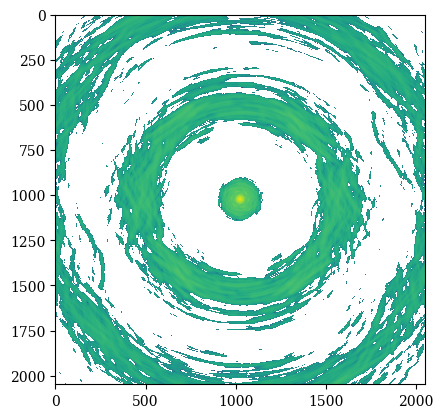

In [11]:
plt.imshow(data, norm=LogNorm())